# Customer Segmentation Analysis (RFM + KMeans)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df=pd.read_csv('customer_segmentation_dataset.csv')
print(df.head())
print(df.info())
print(df.describe())

  CustomerID  Recency  Frequency  Monetary  CustomerLifetimeValue
0      C0001        1         43     38024               54862.87
1      C0002       78         13     10848               20900.73
2      C0003        1         22     34328               48942.30
3      C0004       18         26     55713               94006.09
4      C0005      331          3       226                 488.69
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             300 non-null    object 
 1   Recency                300 non-null    int64  
 2   Frequency              300 non-null    int64  
 3   Monetary               300 non-null    int64  
 4   CustomerLifetimeValue  300 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 11.8+ KB
None
          Recency   Frequency      Monetary  CustomerLifetimeValue
c

In [2]:
print('Missing values:\n',df.isnull().sum())
print('Average Purchase Value:',df['Monetary'].mean())
print('Average Purchase Frequency:',df['Frequency'].mean())
print('Average CLV:',df['CustomerLifetimeValue'].mean())

Missing values:
 CustomerID               0
Recency                  0
Frequency                0
Monetary                 0
CustomerLifetimeValue    0
dtype: int64
Average Purchase Value: 17460.323333333334
Average Purchase Frequency: 17.136666666666667
Average CLV: 31161.739299999997


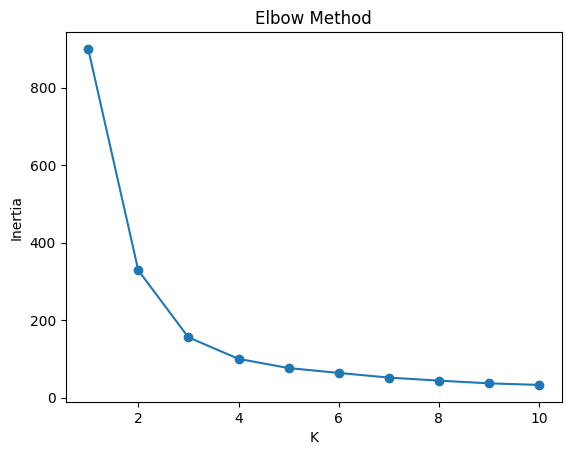

In [3]:
features=df[['Recency','Frequency','Monetary']]
scaler=StandardScaler()
X=scaler.fit_transform(features)
inertia=[]
for k in range(1,11):
 kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
 kmeans.fit(X)
 inertia.append(kmeans.inertia_)
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('K');plt.ylabel('Inertia');plt.title('Elbow Method');plt.show()

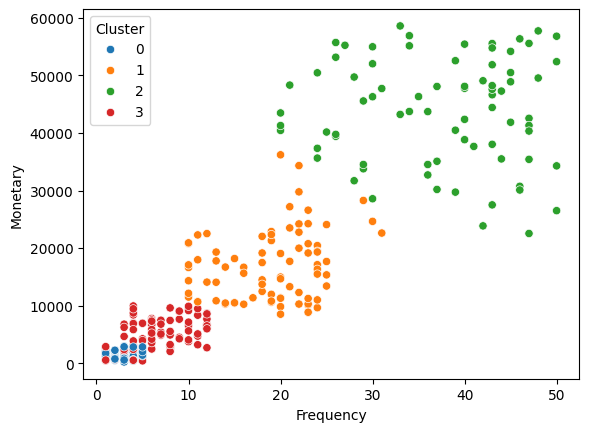

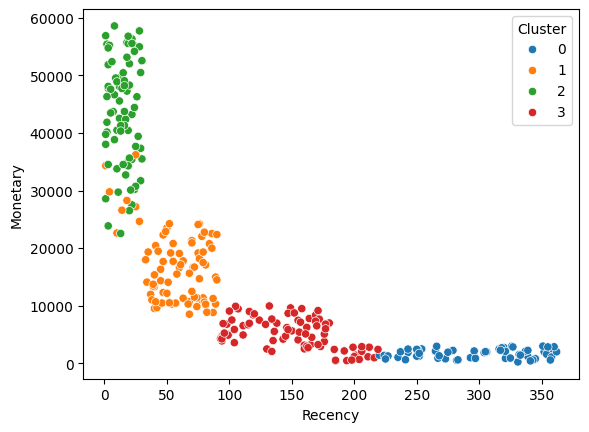

            Recency  Frequency      Monetary  CustomerLifetimeValue
Cluster                                                            
0        298.241379   3.241379   1666.982759            3115.049138
1         58.012048  18.807229  16734.084337           30396.846747
2         14.776316  37.342105  43736.710526           77419.396711
3        151.530120   6.674699   5162.566265            9169.114578


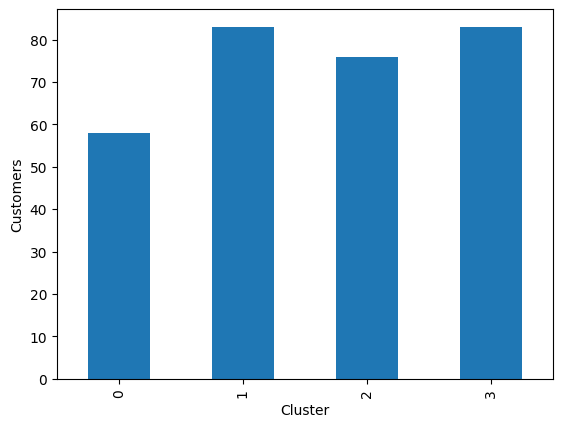

In [4]:
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
df['Cluster']=kmeans.fit_predict(X)
sns.scatterplot(data=df,x='Frequency',y='Monetary',hue='Cluster',palette='tab10')
plt.show()
sns.scatterplot(data=df,x='Recency',y='Monetary',hue='Cluster',palette='tab10')
plt.show()
print(df.groupby('Cluster')[['Recency','Frequency','Monetary','CustomerLifetimeValue']].mean())
df['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Cluster');plt.ylabel('Customers');plt.show()

## Insights\n- Cluster 0: High-value loyal customers → Reward with VIP programs.\n- Cluster 1: Regular customers → Cross-sell and upsell.\n- Cluster 2: Occasional customers → Personalized discounts.\n- Cluster 3: At-risk/lost customers → Win-back campaigns.